# Exploratory Data Analysis — Telco Customer Churn

Basic exploration of the raw dataset: shape, types, missing values, target distribution, and how features relate to churn.

## 1. Setup & Load Data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_DIR = Path.cwd().resolve().parent / "data" / "raw"
csv_path = DATA_DIR / "Telco-Customer-Churn.csv"

df = pd.read_csv(csv_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Shape, Dtypes & Basic Info

In [2]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()

Rows: 7043, Columns: 21
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-nu

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning Checks

`TotalCharges` is read as text — a handful of new customers (tenure = 0) have blank strings instead of numbers. Convert it and flag duplicates / missing values.

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Rows with TotalCharges now null:", df["TotalCharges"].isna().sum())
df.loc[df["TotalCharges"].isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Rows with TotalCharges now null: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [5]:
missing = df.isna().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing if len(missing) else "None")

print("\nDuplicate customerIDs:", df["customerID"].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())

Columns with missing values:
TotalCharges    11
dtype: int64

Duplicate customerIDs: 0
Fully duplicate rows: 0


In [6]:
# Drop the id column for analysis, fill the handful of missing TotalCharges with 0 (tenure = 0 -> no charges yet)
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df_eda = df.drop(columns=["customerID"])

## 4. Target Variable — Churn

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: str


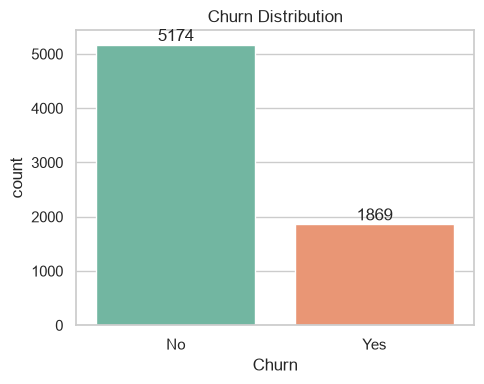

In [7]:
churn_counts = df_eda["Churn"].value_counts()
churn_rate = df_eda["Churn"].value_counts(normalize=True) * 100
print(churn_counts)
print()
print(churn_rate.round(2).astype(str) + "%")

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df_eda, x="Churn", hue="Churn", palette="Set2", legend=False, ax=ax)
ax.set_title("Churn Distribution")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

Churn is imbalanced (roughly 73% No / 27% Yes) — worth keeping in mind for later modeling (stratified splits, class weighting, etc.).

## 5. Numeric Features

In [8]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df_eda[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


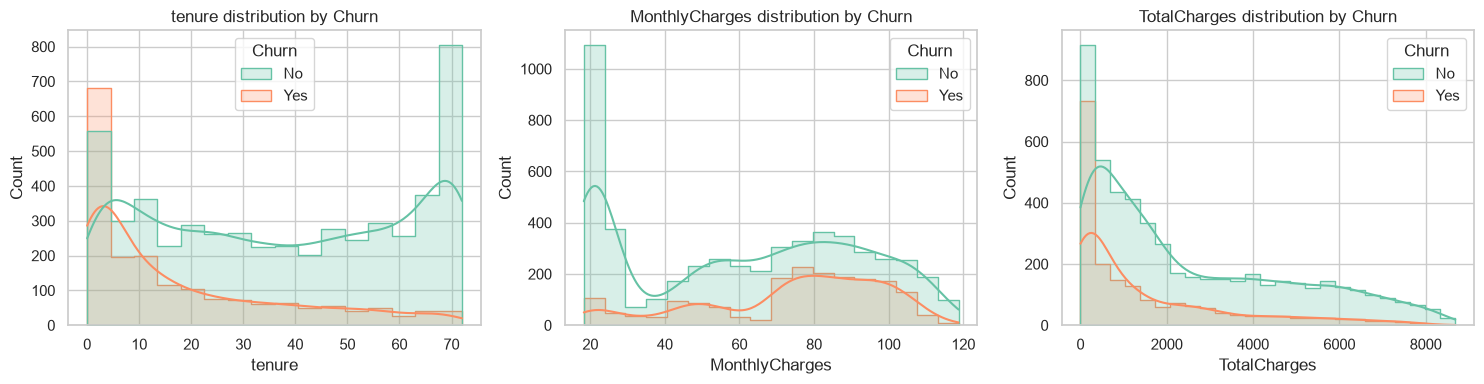

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df_eda, x=col, hue="Churn", kde=True, ax=ax, palette="Set2", element="step")
    ax.set_title(f"{col} distribution by Churn")
plt.tight_layout()
plt.show()

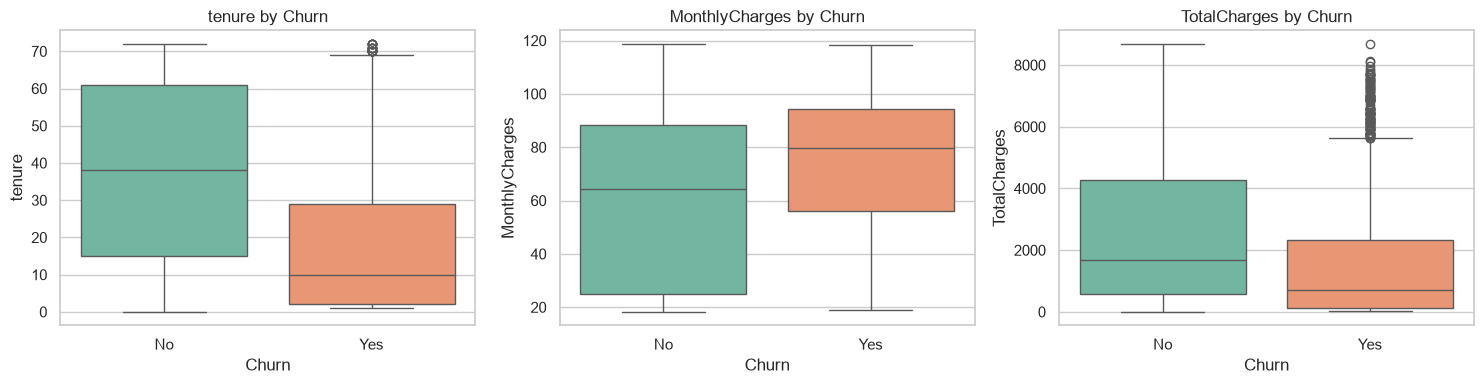

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df_eda, x="Churn", y=col, hue="Churn", palette="Set2", legend=False, ax=ax)
    ax.set_title(f"{col} by Churn")
plt.tight_layout()
plt.show()

**Observation:** churned customers skew toward low tenure and higher monthly charges — consistent with customers leaving early, before they've accumulated high total charges.

## 6. Categorical Features

In [11]:
categorical_cols = df_eda.select_dtypes(include="object").columns.drop("Churn").tolist()
print(f"{len(categorical_cols)} categorical columns:")
print(categorical_cols)

15 categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\iitri\AppData\Local\Temp\ipykernel_7612\2703097862.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_eda.select_dtypes(include="object").columns.drop("Churn").tolist()


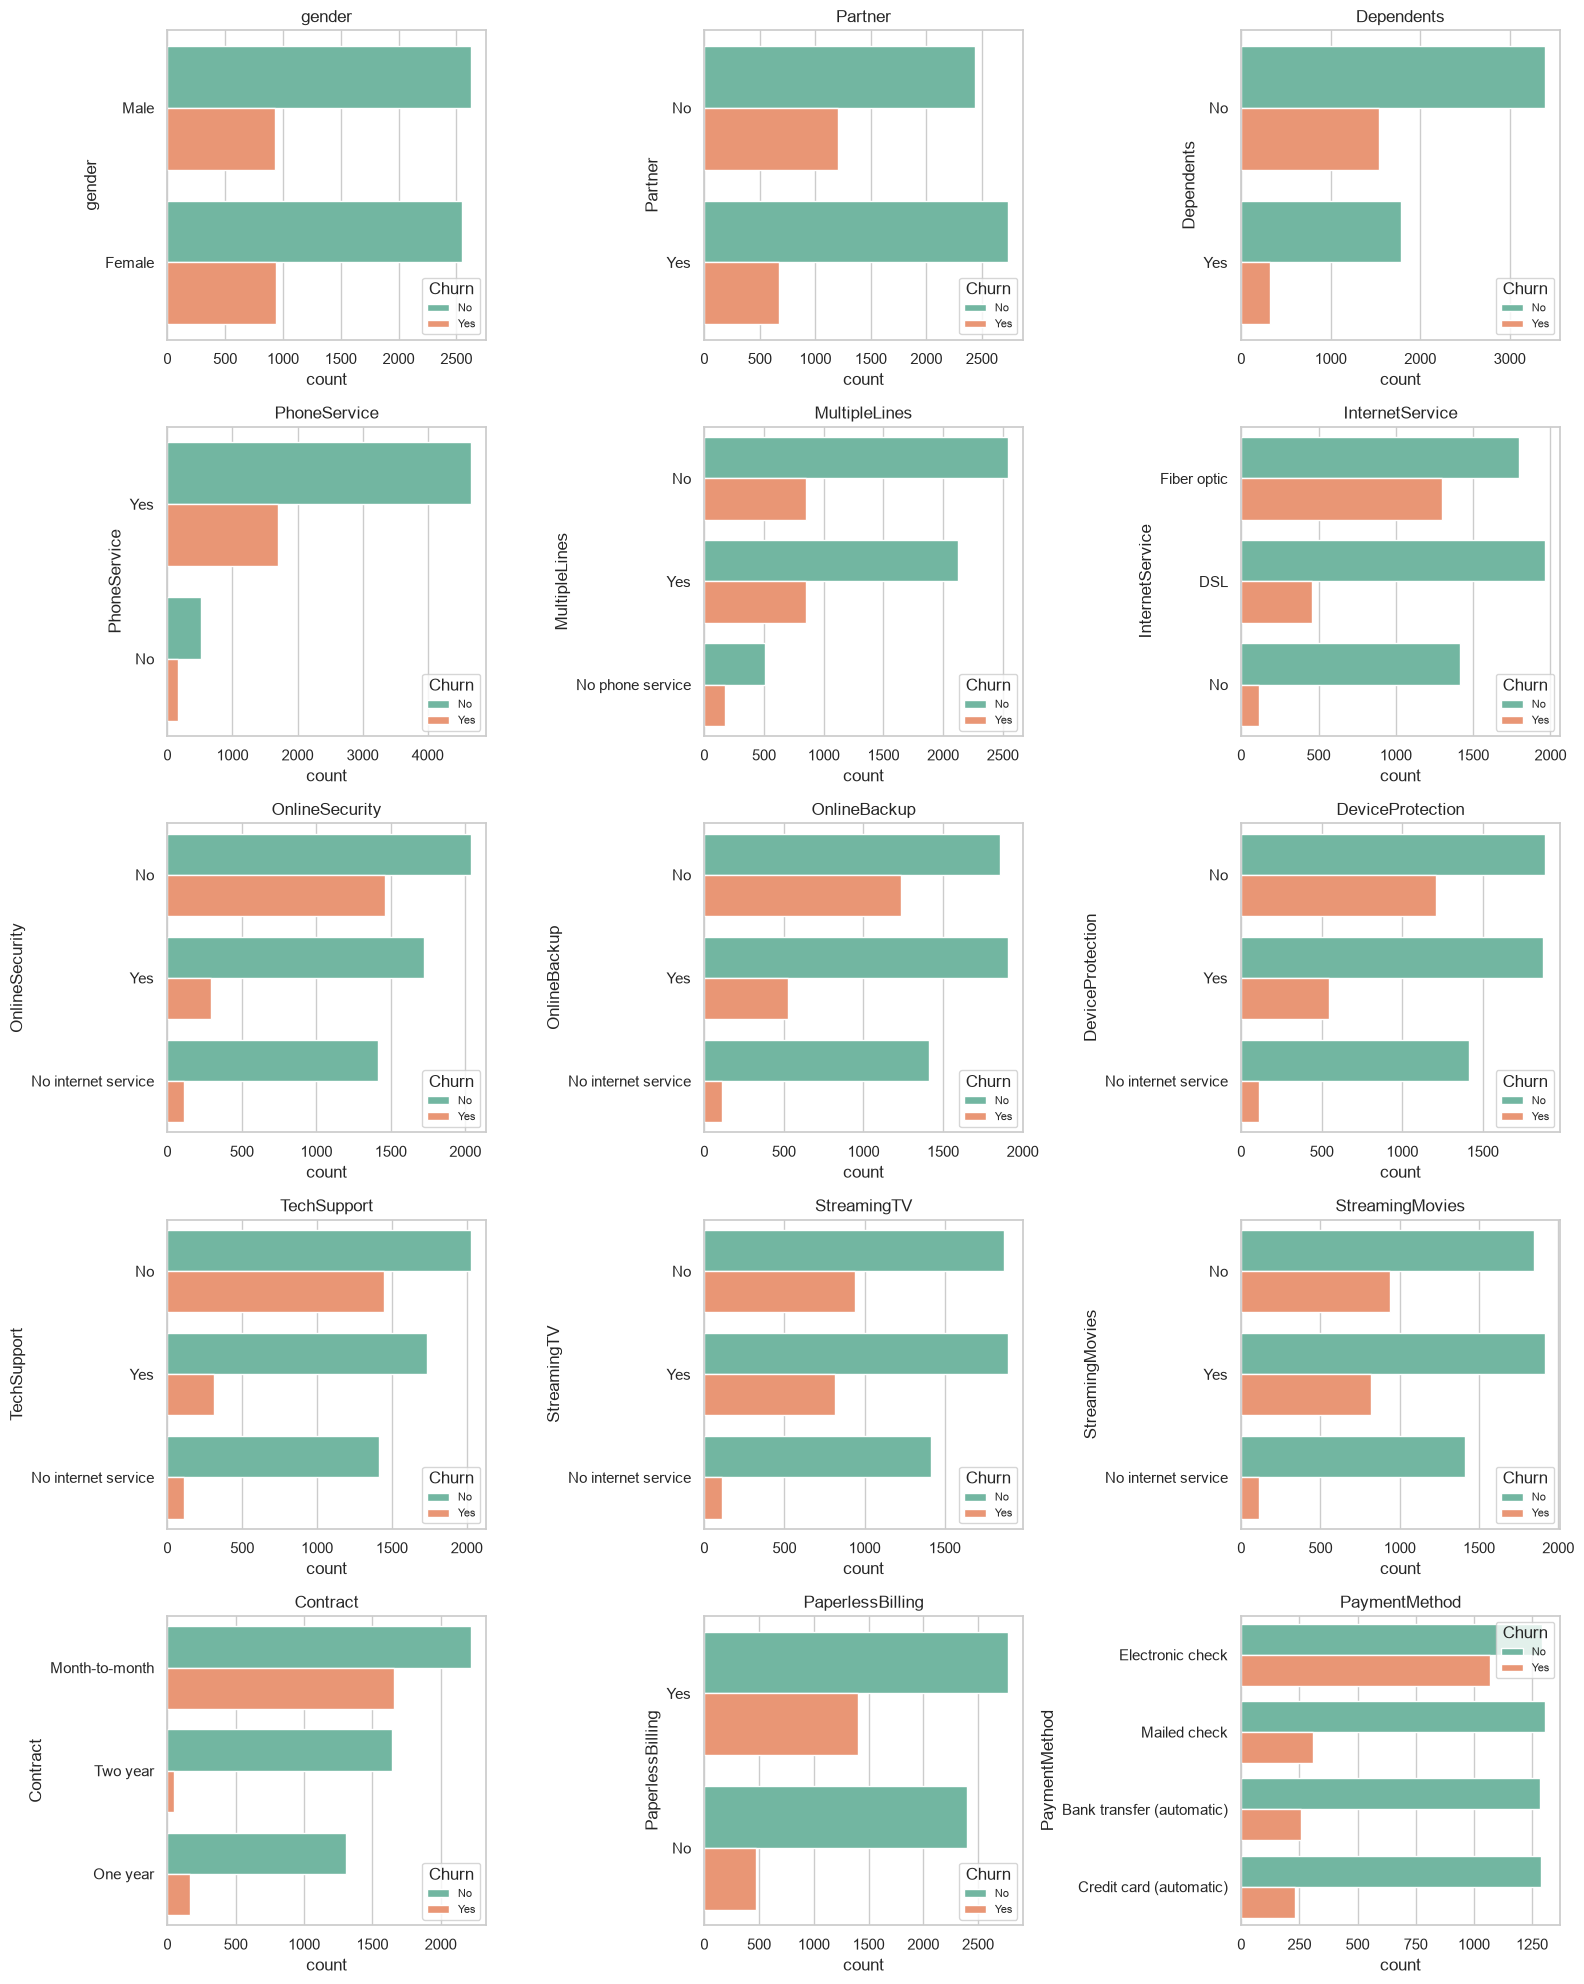

In [12]:
n_cols = 3
n_rows = int(np.ceil(len(categorical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    order = df_eda[col].value_counts().index
    sns.countplot(data=df_eda, y=col, order=order, hue="Churn", palette="Set2", ax=ax)
    ax.set_title(col)
    ax.legend(title="Churn", fontsize=8)

for ax in axes[len(categorical_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Churn Rate by Key Categorical Features

In [13]:
key_cols = ["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity", "PaperlessBilling"]

for col in key_cols:
    rate = df_eda.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values(ascending=False)
    print(f"\nChurn rate by {col}:")
    print(rate.round(1).astype(str) + "%")


Churn rate by Contract:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn, dtype: str

Churn rate by InternetService:
InternetService
Fiber optic    41.9%
DSL            19.0%
No              7.4%
Name: Churn, dtype: str

Churn rate by PaymentMethod:
PaymentMethod
Electronic check             45.3%
Mailed check                 19.1%
Bank transfer (automatic)    16.7%
Credit card (automatic)      15.2%
Name: Churn, dtype: str

Churn rate by TechSupport:
TechSupport
No                     41.6%
Yes                    15.2%
No internet service     7.4%
Name: Churn, dtype: str

Churn rate by OnlineSecurity:
OnlineSecurity
No                     41.8%
Yes                    14.6%
No internet service     7.4%
Name: Churn, dtype: str

Churn rate by PaperlessBilling:
PaperlessBilling
Yes    33.6%
No     16.3%
Name: Churn, dtype: str


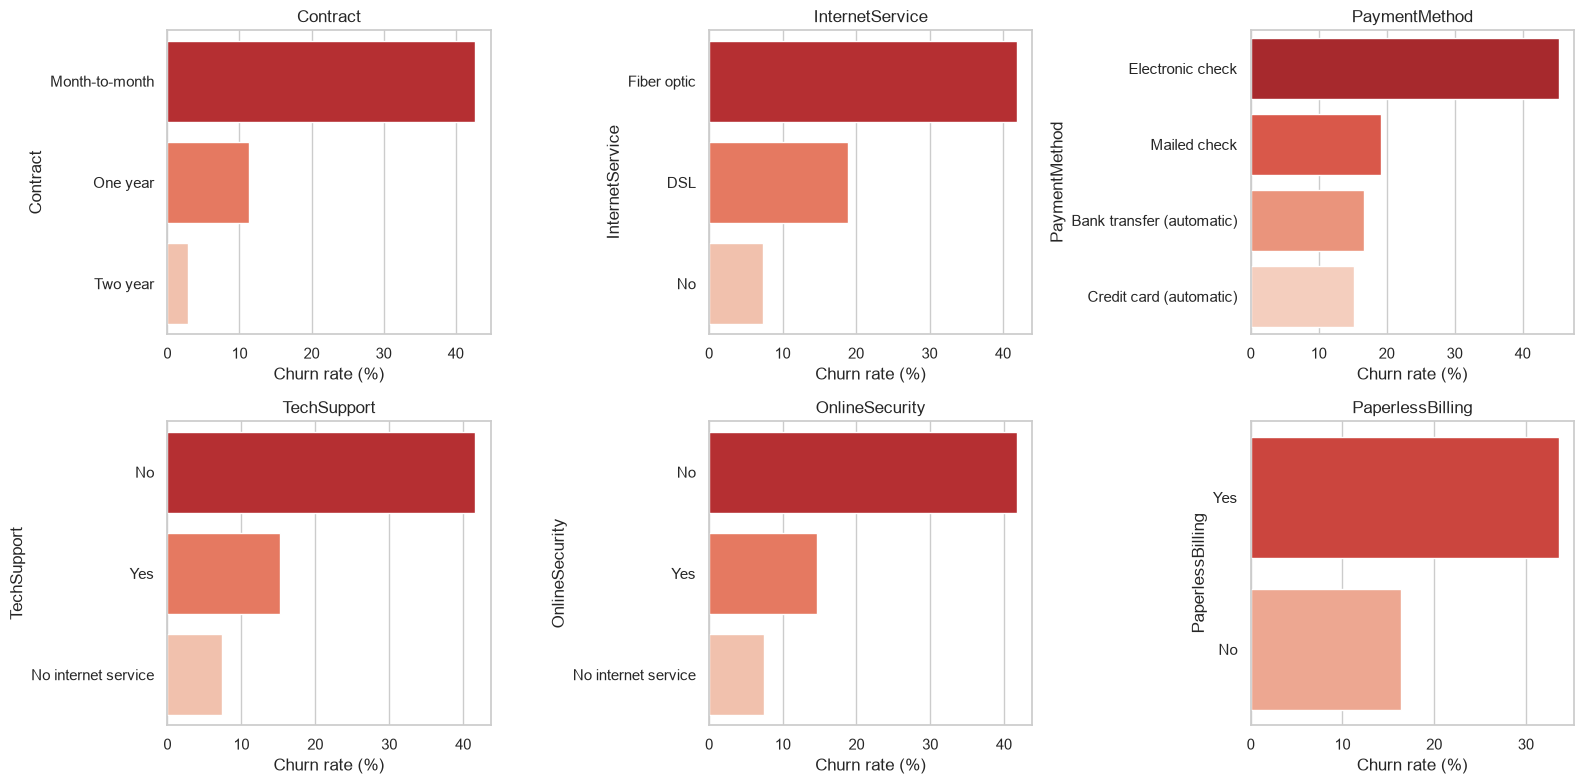

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, key_cols):
    rate = df_eda.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index, hue=rate.index, palette="Reds_r", legend=False, ax=ax)
    ax.set_xlabel("Churn rate (%)")
    ax.set_title(col)

plt.tight_layout()
plt.show()

**Observation:** month-to-month contracts, fiber optic internet, electronic check payment, and lack of tech support / online security are all associated with substantially higher churn rates than their counterparts.

## 8. Correlation Between Numeric Features & Churn

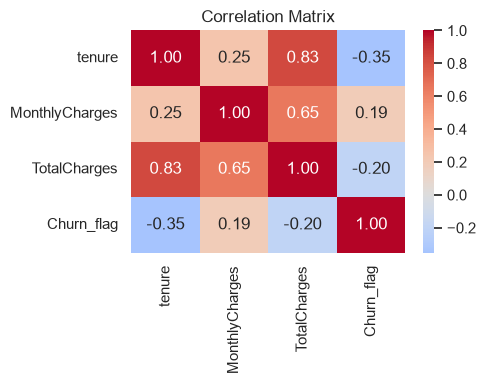

In [15]:
corr_df = df_eda.copy()
corr_df["Churn_flag"] = (corr_df["Churn"] == "Yes").astype(int)

corr = corr_df[numeric_cols + ["Churn_flag"]].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 9. Summary of Findings

- Dataset: 7,043 customers, 21 columns, no duplicate rows/IDs. `TotalCharges` had 11 blank entries (all `tenure == 0`), converted to numeric and filled with 0.
- Target is imbalanced: ~26.5% churn rate.
- Churned customers tend to have **low tenure**, **higher monthly charges**, and **lower total charges** (consistent with leaving early).
- Strongest categorical signals: **month-to-month contract**, **fiber optic internet**, **electronic check payment**, and **no tech support / online security** all correlate with higher churn.
- `tenure` is the strongest numeric correlate with churn (negative correlation); `MonthlyCharges` is weakly positively correlated.

**Next steps:** feature engineering (tenure buckets, service-count aggregates), encoding categoricals, and moving to `02_preprocessing.ipynb`.